# [12.3] Mini VLM from Scratch (solutions)

By the end of this notebook, you will have shown that a frozen patch-based vision encoder plus a learned projector and tiny decoder can answer controlled visual questions, because VQA generalizes from solid training scenes to a disjoint muted rendering style while text-only, image-only, random-visual, background-region, and same-size random-region controls fail, and object-token patching causally flips the answer.

## Core Question

Can a tiny VLM learn to use visual tokens for the answer, rather than memorizing the question or leaning on a text prior?

The section is deliberately finite and inspectable. You will render colored-shape scenes, cache frozen visual patch tokens, train the learned projector/decoder, then patch object tokens from a counterfactual scene into the clean scene. The claim only passes if the muted-style holdout succeeds and an object patch flips the target answer while background and random controls do not.
**Common bug:** treating a successful object patch as localized evidence without checking token geometry and same-size background controls. The claim only passes when object rows flip the answer and matched non-object rows preserve it.


## Learning Objectives

By the end, you should be able to:

1. render and inspect controlled VQA examples;
2. build a detached visual-token cache from a frozen vision encoder;
3. assemble visual prefix tokens and question tokens for a tiny decoder;
4. implement exact-match VQA accuracy and target-vs-counterfactual margins;
5. map object bounding boxes to visual-token rows;
6. patch visual-token caches and intermediate value activations;
7. separate held-out VQA success from text-only, image-only, random-visual, background, and random-region controls; and
8. interpret a layer/position patching heatmap without overclaiming it as a frontier-VLM result.


## Setup

Rendering and the controlled scene schema are plumbing. The visual-token cache, multimodal sequence, metrics, patching, training loop, and final result aggregation are the exercises.


In [1]:
import json
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display

GT_TIER = "GT-0"
EXERCISE_ID = "12_3_mini_vlm_from_scratch"
DIFFICULTY = 4
IMPORTANCE = 5
EXPECTED_RUNTIME = "60-90 minutes; complete release verification trains for 260 CUDA steps"
REQUIRES_GPU = True

chapter = "chapter12_vlm_interpretability"
section = "part3_mini_vlm_from_scratch"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part3_mini_vlm_from_scratch.tests as tests
import part3_mini_vlm_from_scratch.solutions as reference

COLORS = reference.COLORS
SHAPES = reference.SHAPES
ANSWER_VOCAB = reference.ANSWER_VOCAB
ANSWER_TO_ID = reference.ANSWER_TO_ID
QUESTION_TYPES = reference.QUESTION_TYPES
QUESTION_TO_ID = reference.QUESTION_TO_ID
UNKNOWN_QUESTION_ID = reference.UNKNOWN_QUESTION_ID
IMAGE_SIZE = reference.IMAGE_SIZE
PATCH_GRID = reference.PATCH_GRID
OBJECT_SIZE = reference.OBJECT_SIZE
VISION_FEATURE_DIM = reference.VISION_FEATURE_DIM
DEFAULT_D_MODEL = reference.DEFAULT_D_MODEL
DEFAULT_SEED = reference.DEFAULT_SEED
POSITION_ANCHORS = reference.POSITION_ANCHORS
STYLES = reference.STYLES
TRAIN_STYLE = reference.TRAIN_STYLE
HELDOUT_STYLE = reference.HELDOUT_STYLE
POSITIONS = reference.POSITIONS

VQAExample = reference.VQAExample
VQABatch = reference.VQABatch
MiniVLMTrainingResult = reference.MiniVLMTrainingResult
render_controlled_scene = reference.render_controlled_scene
build_vqa_batch = reference.build_vqa_batch
same_size_random_region_indices = reference.same_size_random_region_indices


## Cold Open

Here is the whole causal story before any abstraction. The clean image is a red square and the corrupt image is a blue square. The question stays fixed: "What color is the object?" If the MiniVLM really reads the object tokens, replacing only the object-token rows from the blue image should flip the answer from red to blue. Replacing same-size background rows should not.


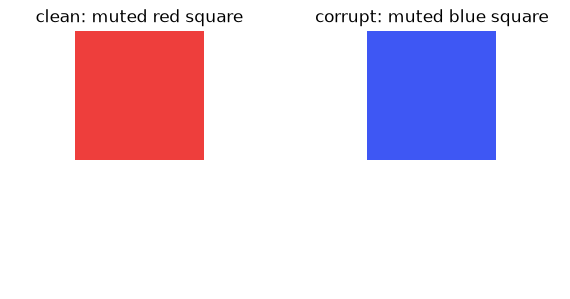

object bbox: (12, 0, 36, 24)
question: What color is the object?
clean answer: red | counterfactual answer: blue


In [2]:
clean_image, clean_bbox = render_controlled_scene(
    "red", "square", "top", style=HELDOUT_STYLE
)
corrupt_image, _ = render_controlled_scene(
    "blue", "square", "top", style=HELDOUT_STYLE
)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, image, title in zip(
    axes,
    [clean_image, corrupt_image],
    ["clean: muted red square", "corrupt: muted blue square"],
):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("object bbox:", clean_bbox)
print("question: What color is the object?")
print("clean answer: red | counterfactual answer: blue")

## Visible Architecture

This is the whole model class used below. The vision tower is frozen and deterministic: it turns each 48x48 image into a 6x6 grid of patch tokens containing mean RGB plus objectness. The learned part is the visual projector, two cross-attention value layers, and the answer head.

The key intervention stages are `cache`, `projected`, `value_0`, and `value_1`.


In [3]:
class FrozenPatchEncoder(nn.Module):
    """Frozen pixel-patch encoder used as the mini VLM vision tower."""

    def __init__(self, *, grid_size: int = PATCH_GRID):
        super().__init__()
        self.grid_size = grid_size

    @property
    def num_tokens(self) -> int:
        return self.grid_size * self.grid_size

    @property
    def feature_dim(self) -> int:
        return VISION_FEATURE_DIM

    def forward(self, images: t.Tensor) -> t.Tensor:
        if images.ndim != 4 or images.shape[1] != 3:
            raise ValueError("images must have shape (batch, 3, height, width).")
        batch, channels, height, width = images.shape
        if height != width or height % self.grid_size != 0:
            raise ValueError("image height/width must be square and divisible by grid_size.")
        patch = height // self.grid_size
        patches = images.float().reshape(
            batch,
            channels,
            self.grid_size,
            patch,
            self.grid_size,
            patch,
        )
        patches = patches.permute(0, 2, 4, 1, 3, 5)
        mean_rgb = patches.mean(dim=(-1, -2))
        nonwhite = (patches < 0.98).any(dim=3).float().mean(dim=(-1, -2))
        tokens = t.cat(
            [
                mean_rgb,
                nonwhite.unsqueeze(-1),
            ],
            dim=-1,
        )
        return tokens.reshape(batch, self.num_tokens, self.feature_dim)


def _replace_token_rows(
    values: t.Tensor,
    patch_indices: tuple[int, ...] | list[int],
    replacement_rows: t.Tensor,
) -> t.Tensor:
    index = t.tensor(tuple(int(i) for i in patch_indices), device=values.device)
    if replacement_rows.ndim != 3:
        raise ValueError("replacement_rows must have shape (batch, patched_tokens, dim).")
    if replacement_rows.shape[1] != index.numel():
        raise ValueError("replacement row count must match patch_indices length.")
    if replacement_rows.shape[0] == 1 and values.shape[0] != 1:
        replacement_rows = replacement_rows.expand(values.shape[0], -1, -1)
    if replacement_rows.shape[0] != values.shape[0]:
        raise ValueError("replacement batch size must be 1 or match values batch size.")
    patched = values.clone()
    patched[:, index] = replacement_rows.to(device=values.device, dtype=values.dtype)
    return patched


class MiniVLM(nn.Module):
    """Tiny cross-attention decoder over visual patch tokens and one question token."""

    def __init__(
        self,
        *,
        vision_feature_dim: int = VISION_FEATURE_DIM,
        d_model: int = DEFAULT_D_MODEL,
        num_visual_tokens: int = PATCH_GRID * PATCH_GRID,
        num_layers: int = 2,
        num_heads: int = 4,
        num_answers: int = len(ANSWER_VOCAB),
    ):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads.")
        self.num_visual_tokens = num_visual_tokens
        self.d_model = d_model
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.visual_projector = nn.Linear(vision_feature_dim, d_model)
        self.question_embed = nn.Embedding(len(QUESTION_TYPES) + 1, d_model)
        self.query_layers = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_layers)])
        self.key_layers = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_layers)])
        self.value_layers = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_layers)])
        self.update_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.LayerNorm(2 * d_model),
                    nn.Linear(2 * d_model, 2 * d_model),
                    nn.GELU(),
                    nn.Linear(2 * d_model, d_model),
                )
                for _ in range(num_layers)
            ]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.answer_head = nn.Linear(d_model, num_answers)
        with t.no_grad():
            self.question_embed.weight[UNKNOWN_QUESTION_ID].zero_()

    def forward(
        self,
        visual_cache: t.Tensor,
        question_ids: t.Tensor,
        *,
        ablate_question: bool = False,
        patch_spec: dict[str, object] | None = None,
        return_cache: bool = False,
    ) -> t.Tensor | tuple[t.Tensor, dict[str, t.Tensor]]:
        if visual_cache.ndim != 3:
            raise ValueError("visual_cache must have shape (batch, visual_tokens, features).")
        if visual_cache.shape[1] != self.num_visual_tokens:
            raise ValueError("visual_cache has the wrong number of visual tokens.")
        if question_ids.ndim != 1 or question_ids.shape[0] != visual_cache.shape[0]:
            raise ValueError("question_ids must have shape (batch,).")

        stage = None if patch_spec is None else str(patch_spec["stage"])
        patch_indices = () if patch_spec is None else tuple(patch_spec["indices"])  # type: ignore[arg-type]
        replacement = None if patch_spec is None else patch_spec["values"]  # type: ignore[index]

        if stage == "cache":
            visual_cache = _replace_token_rows(visual_cache, patch_indices, replacement)  # type: ignore[arg-type]

        visual_tokens = self.visual_projector(visual_cache.float())
        cache: dict[str, t.Tensor] = {}
        if return_cache:
            cache["cache"] = visual_cache.detach()
            cache["projected"] = visual_tokens.detach()
        if stage == "projected":
            visual_tokens = _replace_token_rows(visual_tokens, patch_indices, replacement)  # type: ignore[arg-type]

        question_tokens = self.question_embed(question_ids.to(visual_cache.device))
        if ablate_question:
            question_tokens = t.zeros_like(question_tokens)
        question_state = question_tokens
        batch_size, num_visual_tokens, _ = visual_tokens.shape
        scale = self.head_dim**0.5
        for layer_index in range(self.num_layers):
            query = self.query_layers[layer_index](question_state)
            keys = self.key_layers[layer_index](visual_tokens)
            values = self.value_layers[layer_index](visual_tokens)
            layer_stage = f"value_{layer_index}"
            if return_cache:
                cache[layer_stage] = values.detach()
            if stage == layer_stage:
                values = _replace_token_rows(values, patch_indices, replacement)  # type: ignore[arg-type]
            query = query.reshape(batch_size, self.num_heads, 1, self.head_dim)
            keys = keys.reshape(
                batch_size,
                num_visual_tokens,
                self.num_heads,
                self.head_dim,
            ).transpose(1, 2)
            values_by_head = values.reshape(
                batch_size,
                num_visual_tokens,
                self.num_heads,
                self.head_dim,
            ).transpose(1, 2)
            attention = (query @ keys.transpose(-1, -2) / scale).softmax(dim=-1)
            context = (attention @ values_by_head).transpose(1, 2).reshape(
                batch_size,
                self.d_model,
            )
            update = self.update_layers[layer_index](
                t.cat([question_state, context], dim=-1)
            )
            question_state = question_state + update

        answer_state = self.final_norm(question_state)
        logits = self.answer_head(answer_state)
        if return_cache:
            return logits, cache
        return logits

## Provided Patching Helpers

These helpers are deliberately small and visible. They build one-example clean/corrupt batches and fetch corrupt activations for non-cache patch stages; the core intervention and aggregation are still implemented in the exercises below.


In [4]:
def _next_value(value: str, values: tuple[str, ...]) -> str:
    return values[(values.index(value) + 1) % len(values)]


def build_single_example(
    *,
    color: str,
    shape: str,
    position: str,
    question_type: str,
    style: str = HELDOUT_STYLE,
    split: str = "patch",
) -> VQABatch:
    """Build a one-example VQA batch for intervention experiments."""

    image, bbox = render_controlled_scene(color, shape, position, style=style)
    answer = color if question_type == "color" else shape
    counterfactual = (
        _next_value(color, COLORS) if question_type == "color" else _next_value(shape, SHAPES)
    )
    example = VQAExample(
        image_id=f"{split}_{style}_{position}_{color}_{shape}_{question_type}",
        color=color,
        shape=shape,
        style=style,
        position=position,
        bbox=bbox,
        question_type=question_type,
        question="What color is the object?"
        if question_type == "color"
        else "What shape is the object?",
        answer=answer,
        counterfactual_answer=counterfactual,
        split=split,
    )
    return VQABatch(
        examples=(example,),
        images=image.unsqueeze(0),
        question_ids=t.tensor([QUESTION_TO_ID[question_type]], dtype=t.long),
        labels=t.tensor([ANSWER_TO_ID[answer]], dtype=t.long),
        counterfactual_labels=t.tensor([ANSWER_TO_ID[counterfactual]], dtype=t.long),
    )


def _patch_replacement_for_stage(
    model: MiniVLM,
    corrupt_cache: t.Tensor,
    question_ids: t.Tensor,
    patch_indices: tuple[int, ...],
    stage: str,
) -> t.Tensor:
    if stage == "cache":
        return corrupt_cache[:, patch_indices]
    with t.no_grad():
        _, caches = model(corrupt_cache, question_ids, return_cache=True)
    return caches[stage][:, patch_indices]


def forward_with_random_activation_patch(
    model: MiniVLM,
    clean_cache: t.Tensor,
    question_ids: t.Tensor,
    patch_indices: tuple[int, ...],
    *,
    seed: int = DEFAULT_SEED,
) -> t.Tensor:
    """Patch object rows with same-scale random cache activations."""

    generator = t.Generator(device="cpu").manual_seed(seed)
    mean = clean_cache.detach().cpu().mean()
    std = clean_cache.detach().cpu().std().clamp_min(1e-3)
    replacement = mean + std * t.randn(
        clean_cache.shape[0],
        len(patch_indices),
        clean_cache.shape[-1],
        generator=generator,
    )
    logits = model(
        clean_cache,
        question_ids,
        patch_spec={
            "stage": "cache",
            "indices": patch_indices,
            "values": replacement.to(clean_cache.device),
        },
    )
    assert isinstance(logits, t.Tensor)
    return logits


def _margin_float(logits: t.Tensor, target: int, counterfactual: int) -> float:
    return float((logits[:, target] - logits[:, counterfactual]).detach().cpu().item())

## Controlled Data

The training split uses center/left/right object positions. The held-out split uses top/bottom object positions. That is still a tiny controlled world, but it forces the model to use translation-friendly patch evidence rather than a single memorized location.


In [5]:
train_batch = build_vqa_batch("train")
heldout_batch = build_vqa_batch("heldout")
print("train examples:", len(train_batch.examples), "style:", TRAIN_STYLE)
print("held-out examples:", len(heldout_batch.examples), "style:", HELDOUT_STYLE)

display(pd.DataFrame([
    {
        "image_id": ex.image_id,
        "style": ex.style,
        "question": ex.question,
        "answer": ex.answer,
        "counterfactual": ex.counterfactual_answer,
        "bbox": ex.bbox,
    }
    for ex in heldout_batch.examples[:8]
]))

train examples: 120 style: solid
held-out examples: 120 style: muted


,image_id,style,question,answer,counterfactual,bbox
0,heldout_muted_center_red_square_color,muted,What color is the object?,red,blue,"(12, 12, 36, 36)"
1,heldout_muted_center_red_square_shape,muted,What shape is the object?,square,circle,"(12, 12, 36, 36)"
2,heldout_muted_center_red_circle_color,muted,What color is the object?,red,blue,"(12, 12, 36, 36)"
3,heldout_muted_center_red_circle_shape,muted,What shape is the object?,circle,triangle,"(12, 12, 36, 36)"
4,heldout_muted_center_red_triangle_color,muted,What color is the object?,red,blue,"(12, 12, 36, 36)"
5,heldout_muted_center_red_triangle_shape,muted,What shape is the object?,triangle,square,"(12, 12, 36, 36)"
6,heldout_muted_center_blue_square_color,muted,What color is the object?,blue,green,"(12, 12, 36, 36)"
7,heldout_muted_center_blue_square_shape,muted,What shape is the object?,square,circle,"(12, 12, 36, 36)"


### Exercise - build the visual-token cache

> Difficulty: medium  
> Importance: high  
> You should spend 8-12 minutes on this exercise.

The vision tower is frozen. Your job is to run it once, detach the patch-token tensor, and use that cache for fast VQA training and intervention experiments.


In [6]:
def encode_visual_token_cache(
    encoder: FrozenPatchEncoder,
    images: t.Tensor,
    *,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Encode images once and detach the visual tokens for fast VLM training."""

    target_device = t.device(device)
    encoder = encoder.to(target_device)
    with t.no_grad():
        cache = encoder(images.to(target_device))
    return cache.detach()

In [7]:
tests.test_visual_token_cache_detaches_and_preserves_patch_grid(encode_visual_token_cache)


All tests in `test_visual_token_cache_detaches_and_preserves_patch_grid` passed!


<details>
<summary>Expected output</summary>

The cache shape should be `(72, 36, 4)` for the training split. The objectness feature should be high on colored object patches and exactly zero on pure white background patches.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

A frozen cache makes the causal experiment simpler: if a patch changes the answer later, the thing you changed was a visual-token representation, not image rendering code or a trainable vision tower.

</details>

<details>
<summary>Interpretation</summary>

If this test fails because the cache requires gradients, you are no longer studying a frozen vision encoder. If it fails on shape, later patch indices will silently hit the wrong rows.

</details>

<details>
<summary>Solution</summary>

```python
def encode_visual_token_cache(
    encoder: FrozenPatchEncoder,
    images: t.Tensor,
    *,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Encode images once and detach the visual tokens for fast VLM training."""

    target_device = t.device(device)
    encoder = encoder.to(target_device)
    with t.no_grad():
        cache = encoder(images.to(target_device))
    return cache.detach()
```

</details>


### Exercise - assemble visual tokens and a question token

> Difficulty: medium  
> Importance: high  
> You should spend 8-10 minutes on this exercise.

A MiniVLM is just a visual prefix plus text/question conditioning plus a decoder. Implement the visible sequence that the decoder will reason over.


In [8]:
def build_multimodal_sequence(
    model: MiniVLM,
    visual_cache: t.Tensor,
    question_ids: t.Tensor,
) -> t.Tensor:
    """Project visual tokens and append the question token."""

    visual_tokens = model.visual_projector(visual_cache.float())
    question_tokens = model.question_embed(question_ids.to(visual_tokens.device)).unsqueeze(1)
    return t.cat([visual_tokens, question_tokens], dim=1)

In [9]:
tests.test_multimodal_sequence_has_visual_prefix_and_question_token(build_multimodal_sequence)


All tests in `test_multimodal_sequence_has_visual_prefix_and_question_token` passed!


<details>
<summary>Expected output</summary>

For a batch of 3 examples and a 6x6 patch grid, the sequence should have shape `(3, 37, d_model)`: 36 visual tokens followed by one question token.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

The question token is not decoration. Without it, the same image cannot tell the model whether to answer with a color word or a shape word.

</details>

<details>
<summary>Interpretation</summary>

This is the smallest version of the BLIP-2/LLaVA pattern: frozen visual features are projected into the language-model space before a text-conditioned decoder reads them.

</details>

<details>
<summary>Solution</summary>

```python
def build_multimodal_sequence(
    model: MiniVLM,
    visual_cache: t.Tensor,
    question_ids: t.Tensor,
) -> t.Tensor:
    """Project visual tokens and append the question token."""

    visual_tokens = model.visual_projector(visual_cache.float())
    question_tokens = model.question_embed(question_ids.to(visual_tokens.device)).unsqueeze(1)
    return t.cat([visual_tokens, question_tokens], dim=1)
```

</details>


### Exercise - write the VQA metric and answer margin

> Difficulty: low  
> Importance: high  
> You should spend 6-8 minutes on this exercise.

Accuracy tells us whether the answer is right. The target-vs-counterfactual margin gives a signed scalar for causal patching.


In [10]:
def vqa_accuracy(logits: t.Tensor, labels: t.Tensor) -> float:
    """Return exact-match VQA accuracy."""

    if logits.ndim != 2:
        raise ValueError("logits must have shape (batch, answers).")
    if labels.ndim != 1 or labels.shape[0] != logits.shape[0]:
        raise ValueError("labels must have shape (batch,).")
    return float((logits.argmax(dim=-1) == labels.to(logits.device)).float().mean().item())


def answer_margin(
    logits: t.Tensor,
    target_labels: t.Tensor,
    counterfactual_labels: t.Tensor,
) -> t.Tensor:
    """Return target-answer logit minus counterfactual-answer logit."""

    if target_labels.shape != counterfactual_labels.shape:
        raise ValueError("target and counterfactual labels must have matching shapes.")
    target = logits.gather(1, target_labels.to(logits.device).reshape(-1, 1)).squeeze(1)
    counter = logits.gather(
        1,
        counterfactual_labels.to(logits.device).reshape(-1, 1),
    ).squeeze(1)
    return target - counter

In [11]:
tests.test_vqa_accuracy_and_answer_margin(vqa_accuracy, answer_margin)


All tests in `test_vqa_accuracy_and_answer_margin` passed!


<details>
<summary>Expected output</summary>

The toy logits in the test have accuracy `0.5` and margins `[3.0, -1.0]`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Patching needs a continuous metric. A flip from positive to negative target-minus-counterfactual margin means the intervention changed which answer the model prefers.

</details>

<details>
<summary>Interpretation</summary>

Do not patch against raw accuracy alone. Accuracy changes are too coarse for a single counterfactual pair; margins give you direction and size.

</details>

<details>
<summary>Solution</summary>

```python
def vqa_accuracy(logits: t.Tensor, labels: t.Tensor) -> float:
    """Return exact-match VQA accuracy."""

    if logits.ndim != 2:
        raise ValueError("logits must have shape (batch, answers).")
    if labels.ndim != 1 or labels.shape[0] != logits.shape[0]:
        raise ValueError("labels must have shape (batch,).")
    return float((logits.argmax(dim=-1) == labels.to(logits.device)).float().mean().item())


def answer_margin(
    logits: t.Tensor,
    target_labels: t.Tensor,
    counterfactual_labels: t.Tensor,
) -> t.Tensor:
    """Return target-answer logit minus counterfactual-answer logit."""

    if target_labels.shape != counterfactual_labels.shape:
        raise ValueError("target and counterfactual labels must have matching shapes.")
    target = logits.gather(1, target_labels.to(logits.device).reshape(-1, 1)).squeeze(1)
    counter = logits.gather(
        1,
        counterfactual_labels.to(logits.device).reshape(-1, 1),
    ).squeeze(1)
    return target - counter
```

</details>


### Exercise - map a bounding box to visual-token indices

> Difficulty: medium  
> Importance: high  
> You should spend 10-12 minutes on this exercise.

Object-region patching only means something if the object pixels map to the intended visual-token rows. Implement overlap-based bbox-to-token mapping.


In [12]:
def patch_indices_from_bbox(
    bbox: tuple[int, int, int, int],
    *,
    image_size: int = IMAGE_SIZE,
    grid_size: int = PATCH_GRID,
) -> tuple[int, ...]:
    """Return patch-token indices whose image patches overlap ``bbox``."""

    x1, y1, x2, y2 = bbox
    if not (0 <= x1 < x2 <= image_size and 0 <= y1 < y2 <= image_size):
        raise ValueError("bbox must lie inside the image with positive area.")
    if image_size % grid_size != 0:
        raise ValueError("image_size must be divisible by grid_size.")
    patch = image_size // grid_size
    indices: list[int] = []
    for row in range(grid_size):
        patch_y1 = row * patch
        patch_y2 = patch_y1 + patch
        for col in range(grid_size):
            patch_x1 = col * patch
            patch_x2 = patch_x1 + patch
            overlaps = max(x1, patch_x1) < min(x2, patch_x2) and max(y1, patch_y1) < min(
                y2, patch_y2
            )
            if overlaps:
                indices.append(row * grid_size + col)
    if not indices:
        raise ValueError("bbox does not overlap any patch token.")
    return tuple(indices)

In [13]:
tests.test_patch_indices_from_bbox_matches_known_grid(patch_indices_from_bbox)


All tests in `test_patch_indices_from_bbox_matches_known_grid` passed!


<details>
<summary>Expected output</summary>

The centered 24x24 object starts between 8px patch boundaries, so in a 48x48 image with a 6x6 grid it overlaps a 4x4 token block: `(7, 8, 9, 10, 13, 14, 15, 16, 19, 20, 21, 22, 25, 26, 27, 28)`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Use strict positive overlap between pixel bbox and patch cell. Boundary-touching without area should not count as overlap.

</details>

<details>
<summary>Interpretation</summary>

This is where many VLM attribution demos go wrong: a convincing-looking patch can be measuring a background edge unless token geometry is explicit.

</details>

<details>
<summary>Solution</summary>

```python
def patch_indices_from_bbox(
    bbox: tuple[int, int, int, int],
    *,
    image_size: int = IMAGE_SIZE,
    grid_size: int = PATCH_GRID,
) -> tuple[int, ...]:
    """Return patch-token indices whose image patches overlap ``bbox``."""

    x1, y1, x2, y2 = bbox
    if not (0 <= x1 < x2 <= image_size and 0 <= y1 < y2 <= image_size):
        raise ValueError("bbox must lie inside the image with positive area.")
    if image_size % grid_size != 0:
        raise ValueError("image_size must be divisible by grid_size.")
    patch = image_size // grid_size
    indices: list[int] = []
    for row in range(grid_size):
        patch_y1 = row * patch
        patch_y2 = patch_y1 + patch
        for col in range(grid_size):
            patch_x1 = col * patch
            patch_x2 = patch_x1 + patch
            overlaps = max(x1, patch_x1) < min(x2, patch_x2) and max(y1, patch_y1) < min(
                y2, patch_y2
            )
            if overlaps:
                indices.append(row * grid_size + col)
    if not indices:
        raise ValueError("bbox does not overlap any patch token.")
    return tuple(indices)
```

</details>


### Exercise - patch visual-token rows

> Difficulty: medium  
> Importance: high  
> You should spend 8-10 minutes on this exercise.

Activation patching is a clone-and-replace operation. Replace selected clean visual-token rows with corrupt rows and leave every other token untouched.


In [14]:
def patch_visual_tokens(
    clean_cache: t.Tensor,
    corrupt_cache: t.Tensor,
    patch_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    """Return ``clean_cache`` with selected token rows replaced by ``corrupt_cache``."""

    if clean_cache.shape != corrupt_cache.shape:
        raise ValueError("clean_cache and corrupt_cache must have the same shape.")
    if clean_cache.ndim != 3:
        raise ValueError("visual caches must have shape (batch, tokens, features).")
    if len(patch_indices) == 0:
        raise ValueError("patch_indices must be nonempty.")
    index = t.tensor(tuple(int(i) for i in patch_indices), device=clean_cache.device)
    if index.min() < 0 or index.max() >= clean_cache.shape[1]:
        raise ValueError("patch index out of range.")
    if len(set(index.detach().cpu().tolist())) != index.numel():
        raise ValueError("patch_indices must be unique.")
    patched = clean_cache.clone()
    patched[:, index] = corrupt_cache[:, index].to(
        device=patched.device,
        dtype=patched.dtype,
    )
    return patched

In [15]:
tests.test_patch_visual_tokens_replaces_only_selected_rows(patch_visual_tokens)


All tests in `test_patch_visual_tokens_replaces_only_selected_rows` passed!


<details>
<summary>Expected output</summary>

Only selected token rows become corrupt values. The original clean cache remains unchanged, and duplicate patch indices are rejected.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Use a clone. Silent in-place mutation makes later clean/corrupt comparisons meaningless.

</details>

<details>
<summary>Interpretation</summary>

This is the causal intervention. Everything before this cell was setup for making this row replacement interpretable.

</details>

<details>
<summary>Solution</summary>

```python
def patch_visual_tokens(
    clean_cache: t.Tensor,
    corrupt_cache: t.Tensor,
    patch_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    """Return ``clean_cache`` with selected token rows replaced by ``corrupt_cache``."""

    if clean_cache.shape != corrupt_cache.shape:
        raise ValueError("clean_cache and corrupt_cache must have the same shape.")
    if clean_cache.ndim != 3:
        raise ValueError("visual caches must have shape (batch, tokens, features).")
    if len(patch_indices) == 0:
        raise ValueError("patch_indices must be nonempty.")
    index = t.tensor(tuple(int(i) for i in patch_indices), device=clean_cache.device)
    if index.min() < 0 or index.max() >= clean_cache.shape[1]:
        raise ValueError("patch index out of range.")
    if len(set(index.detach().cpu().tolist())) != index.numel():
        raise ValueError("patch_indices must be unique.")
    patched = clean_cache.clone()
    patched[:, index] = corrupt_cache[:, index].to(
        device=patched.device,
        dtype=patched.dtype,
    )
    return patched
```

</details>


### Exercise - exact toy object patching

> Difficulty: medium  
> Importance: high  
> You should spend 10-12 minutes on this exercise.

Before trusting a trained MiniVLM, prove the expected intervention behavior in an exact toy contribution game with known object tokens.


In [16]:
def toy_ground_truth_patch_report(
    *,
    grid_size: int = PATCH_GRID,
    target_answer: str = "red",
    counterfactual_answer: str = "blue",
) -> dict[str, object]:
    """Exact oracle showing why object patching should flip this toy game."""

    num_tokens = grid_size * grid_size
    object_indices = patch_indices_from_bbox(
        POSITION_ANCHORS["center"]
        + (
            POSITION_ANCHORS["center"][0] + OBJECT_SIZE,
            POSITION_ANCHORS["center"][1] + OBJECT_SIZE,
        ),
        grid_size=grid_size,
    )
    background_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=num_tokens,
        seed=0,
    )
    random_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=num_tokens,
        seed=1,
    )
    target = ANSWER_TO_ID[target_answer]
    counter = ANSWER_TO_ID[counterfactual_answer]
    clean = t.zeros(1, num_tokens, len(ANSWER_VOCAB))
    corrupt = t.zeros_like(clean)
    clean[:, object_indices, target] = 1.0
    clean[:, object_indices, counter] = -0.25
    corrupt[:, object_indices, counter] = 1.0
    corrupt[:, object_indices, target] = -0.25

    def margin(cache: t.Tensor) -> float:
        logits = cache.sum(dim=1)
        return float((logits[:, target] - logits[:, counter]).item())

    object_patched = patch_visual_tokens(clean, corrupt, object_indices)
    background_patched = patch_visual_tokens(clean, corrupt, background_indices)
    random_patched = patch_visual_tokens(clean, corrupt, random_indices)
    return {
        "claim_scope": "exact_toy_visual_token_contribution_game",
        "object_indices": object_indices,
        "background_indices": background_indices,
        "random_indices": random_indices,
        "clean_margin": margin(clean),
        "corrupt_margin": margin(corrupt),
        "object_patch_margin": margin(object_patched),
        "background_patch_margin": margin(background_patched),
        "random_patch_margin": margin(random_patched),
        "object_patch_flips": margin(object_patched) < 0,
        "background_patch_preserves": margin(background_patched) > 0,
        "random_patch_preserves": margin(random_patched) > 0,
        "object_beats_background": margin(background_patched) - margin(object_patched) > 5.0,
    }

In [17]:
tests.test_toy_ground_truth_patch_report_has_exact_controls(toy_ground_truth_patch_report)


All tests in `test_toy_ground_truth_patch_report_has_exact_controls` passed!


<details>
<summary>Expected output</summary>

The clean target margin is positive, the corrupt margin is negative, object patching flips the margin, and background/random-region patching preserves it.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Make token contributions additively. Object tokens carry the answer; background and random-region tokens do not.

</details>

<details>
<summary>Interpretation</summary>

This is the toy ground truth. If the trained model disagrees later, the lesson is not that patching is magic; it is that the trained model may not use the object tokens cleanly.

</details>

<details>
<summary>Solution</summary>

```python
def toy_ground_truth_patch_report(
    *,
    grid_size: int = PATCH_GRID,
    target_answer: str = "red",
    counterfactual_answer: str = "blue",
) -> dict[str, object]:
    """Exact oracle showing why object patching should flip this toy game."""

    num_tokens = grid_size * grid_size
    object_indices = patch_indices_from_bbox(
        POSITION_ANCHORS["center"]
        + (
            POSITION_ANCHORS["center"][0] + OBJECT_SIZE,
            POSITION_ANCHORS["center"][1] + OBJECT_SIZE,
        ),
        grid_size=grid_size,
    )
    background_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=num_tokens,
        seed=0,
    )
    random_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=num_tokens,
        seed=1,
    )
    target = ANSWER_TO_ID[target_answer]
    counter = ANSWER_TO_ID[counterfactual_answer]
    clean = t.zeros(1, num_tokens, len(ANSWER_VOCAB))
    corrupt = t.zeros_like(clean)
    clean[:, object_indices, target] = 1.0
    clean[:, object_indices, counter] = -0.25
    corrupt[:, object_indices, counter] = 1.0
    corrupt[:, object_indices, target] = -0.25

    def margin(cache: t.Tensor) -> float:
        logits = cache.sum(dim=1)
        return float((logits[:, target] - logits[:, counter]).item())

    object_patched = patch_visual_tokens(clean, corrupt, object_indices)
    background_patched = patch_visual_tokens(clean, corrupt, background_indices)
    random_patched = patch_visual_tokens(clean, corrupt, random_indices)
    return {
        "claim_scope": "exact_toy_visual_token_contribution_game",
        "object_indices": object_indices,
        "background_indices": background_indices,
        "random_indices": random_indices,
        "clean_margin": margin(clean),
        "corrupt_margin": margin(corrupt),
        "object_patch_margin": margin(object_patched),
        "background_patch_margin": margin(background_patched),
        "random_patch_margin": margin(random_patched),
        "object_patch_flips": margin(object_patched) < 0,
        "background_patch_preserves": margin(background_patched) > 0,
        "random_patch_preserves": margin(random_patched) > 0,
        "object_beats_background": margin(background_patched) - margin(object_patched) > 5.0,
    }
```

</details>


## Toy Ground Truth Before the Trained Model

Run the exact contribution game before moving on. This is not the final result; it is the oracle that tells us what should happen when object tokens carry answer evidence and background tokens do not.


In [18]:
toy_report = toy_ground_truth_patch_report()
display(pd.DataFrame([
    {"condition": "clean", "target_minus_counterfactual": toy_report["clean_margin"]},
    {"condition": "corrupt", "target_minus_counterfactual": toy_report["corrupt_margin"]},
    {"condition": "object patch", "target_minus_counterfactual": toy_report["object_patch_margin"]},
    {"condition": "background patch", "target_minus_counterfactual": toy_report["background_patch_margin"]},
    {"condition": "same-size random region", "target_minus_counterfactual": toy_report["random_patch_margin"]},
]))
print({k: toy_report[k] for k in ["object_patch_flips", "background_patch_preserves", "random_patch_preserves"]})


,condition,target_minus_counterfactual
0,clean,20.0
1,corrupt,-20.0
2,object patch,-20.0
3,background patch,20.0
4,same-size random region,20.0


{'object_patch_flips': True, 'background_patch_preserves': True, 'random_patch_preserves': True}


### Exercise - train and evaluate the MiniVLM

> Difficulty: high  
> Importance: high  
> You should spend 15-20 minutes on this exercise.

Train the learned projector and decoder on solid scenes, then evaluate the same colors, shapes, and positions rendered in a disjoint muted style. Then check whether the joint model beats text-only, image-only, and random-visual baselines on the disjoint muted rendering style.


In [19]:
def train_mini_vlm(
    *,
    steps: int = 320,
    lr: float = 3e-3,
    seed: int = DEFAULT_SEED,
    device: str | t.device = "cpu",
) -> MiniVLMTrainingResult:
    """Train on solid scenes and evaluate on the disjoint muted style."""

    target_device = t.device(device)
    if target_device.type == "cpu" and t.get_num_threads() > 4:
        t.set_num_threads(4)
    t.manual_seed(seed)
    encoder = FrozenPatchEncoder().to(target_device)
    train_batch = build_vqa_batch("train")
    heldout_batch = build_vqa_batch("heldout")
    train_cache = encode_visual_token_cache(encoder, train_batch.images, device=target_device)
    heldout_cache = encode_visual_token_cache(encoder, heldout_batch.images, device=target_device)
    train_questions = train_batch.question_ids.to(target_device)
    train_labels = train_batch.labels.to(target_device)
    heldout_questions = heldout_batch.question_ids.to(target_device)
    heldout_labels = heldout_batch.labels.to(target_device)

    model = MiniVLM().to(target_device)
    optimizer = t.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    losses: list[float] = []
    for step in range(steps):
        logits = model(train_cache, train_questions)
        assert isinstance(logits, t.Tensor)
        loss = F.cross_entropy(logits, train_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % max(1, steps // 80) == 0 or step == steps - 1:
            losses.append(float(loss.detach().cpu().item()))

    model.eval()
    with t.no_grad():
        train_logits = model(train_cache, train_questions)
        heldout_logits = model(heldout_cache, heldout_questions)
    assert isinstance(train_logits, t.Tensor)
    assert isinstance(heldout_logits, t.Tensor)
    return MiniVLMTrainingResult(
        model=model,
        encoder=encoder,
        train_batch=train_batch,
        heldout_batch=heldout_batch,
        train_cache=train_cache.detach(),
        heldout_cache=heldout_cache.detach(),
        losses=tuple(losses),
        train_accuracy=vqa_accuracy(train_logits, train_labels),
        heldout_accuracy=vqa_accuracy(heldout_logits, heldout_labels),
    )


def modality_baseline_report(training: MiniVLMTrainingResult) -> dict[str, float]:
    """Compare joint VQA to text-only, image-only, and random-visual baselines."""

    model = training.model
    cache = training.heldout_cache
    question_ids = training.heldout_batch.question_ids.to(cache.device)
    labels = training.heldout_batch.labels.to(cache.device)
    generator = t.Generator(device="cpu").manual_seed(DEFAULT_SEED)
    permutation = t.randperm(cache.shape[0], generator=generator).to(cache.device)
    with t.no_grad():
        joint = model(cache, question_ids)
        text_only = model(t.zeros_like(cache), question_ids)
        image_only = model(cache, question_ids, ablate_question=True)
        random_visual = model(cache[permutation], question_ids)
    assert isinstance(joint, t.Tensor)
    assert isinstance(text_only, t.Tensor)
    assert isinstance(image_only, t.Tensor)
    assert isinstance(random_visual, t.Tensor)
    return {
        "joint_accuracy": vqa_accuracy(joint, labels),
        "text_only_accuracy": vqa_accuracy(text_only, labels),
        "image_only_accuracy": vqa_accuracy(image_only, labels),
        "random_visual_accuracy": vqa_accuracy(random_visual, labels),
    }

In [20]:
training = train_mini_vlm(steps=260, device="cpu")
baselines = modality_baseline_report(training)
tests.check_training_and_baselines(training, baselines)
print("train accuracy:", training.train_accuracy)
print("held-out muted-style accuracy:", training.heldout_accuracy)
display(pd.DataFrame([baselines]))

Training and modality-control checks passed!
train accuracy: 1.0
held-out muted-style accuracy: 1.0


,joint_accuracy,text_only_accuracy,image_only_accuracy,random_visual_accuracy
0,1.0,0.291667,0.166667,0.291667


<details>
<summary>Expected output</summary>

The reference run reaches held-out muted-style accuracy `1.0`; text-only is about `0.29`, image-only about `0.17`, and random visual about `0.29`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Use full-batch cross entropy here. This is a tiny controlled course model, so deterministic training is better than minibatch noise.

</details>

<details>
<summary>Interpretation</summary>

The text-only baseline fails because the question alone does not contain color or shape. The image-only baseline fails because the image alone does not tell the decoder which answer type to emit.

</details>

<details>
<summary>Solution</summary>

```python
def train_mini_vlm(
    *,
    steps: int = 320,
    lr: float = 3e-3,
    seed: int = DEFAULT_SEED,
    device: str | t.device = "cpu",
) -> MiniVLMTrainingResult:
    """Train the mini VLM on controlled scenes."""

    target_device = t.device(device)
    t.manual_seed(seed)
    encoder = FrozenPatchEncoder().to(target_device)
    train_batch = build_vqa_batch("train")
    heldout_batch = build_vqa_batch("heldout")
    train_cache = encode_visual_token_cache(encoder, train_batch.images, device=target_device)
    heldout_cache = encode_visual_token_cache(encoder, heldout_batch.images, device=target_device)
    train_questions = train_batch.question_ids.to(target_device)
    train_labels = train_batch.labels.to(target_device)
    heldout_questions = heldout_batch.question_ids.to(target_device)
    heldout_labels = heldout_batch.labels.to(target_device)

    model = MiniVLM().to(target_device)
    optimizer = t.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    losses: list[float] = []
    for step in range(steps):
        logits = model(train_cache, train_questions)
        assert isinstance(logits, t.Tensor)
        loss = F.cross_entropy(logits, train_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % max(1, steps // 80) == 0 or step == steps - 1:
            losses.append(float(loss.detach().cpu().item()))

    model.eval()
    with t.no_grad():
        train_logits = model(train_cache, train_questions)
        heldout_logits = model(heldout_cache, heldout_questions)
    assert isinstance(train_logits, t.Tensor)
    assert isinstance(heldout_logits, t.Tensor)
    return MiniVLMTrainingResult(
        model=model,
        encoder=encoder,
        train_batch=train_batch,
        heldout_batch=heldout_batch,
        train_cache=train_cache.detach(),
        heldout_cache=heldout_cache.detach(),
        losses=tuple(losses),
        train_accuracy=vqa_accuracy(train_logits, train_labels),
        heldout_accuracy=vqa_accuracy(heldout_logits, heldout_labels),
    )


def modality_baseline_report(training: MiniVLMTrainingResult) -> dict[str, float]:
    """Compare joint VQA to text-only, image-only, and random-visual baselines."""

    model = training.model
    cache = training.heldout_cache
    question_ids = training.heldout_batch.question_ids.to(cache.device)
    labels = training.heldout_batch.labels.to(cache.device)
    generator = t.Generator(device="cpu").manual_seed(DEFAULT_SEED)
    permutation = t.randperm(cache.shape[0], generator=generator).to(cache.device)
    with t.no_grad():
        joint = model(cache, question_ids)
        text_only = model(t.zeros_like(cache), question_ids)
        image_only = model(cache, question_ids, ablate_question=True)
        random_visual = model(cache[permutation], question_ids)
    assert isinstance(joint, t.Tensor)
    assert isinstance(text_only, t.Tensor)
    assert isinstance(image_only, t.Tensor)
    assert isinstance(random_visual, t.Tensor)
    return {
        "joint_accuracy": vqa_accuracy(joint, labels),
        "text_only_accuracy": vqa_accuracy(text_only, labels),
        "image_only_accuracy": vqa_accuracy(image_only, labels),
        "random_visual_accuracy": vqa_accuracy(random_visual, labels),
    }
```

</details>


### Exercise - patch object tokens in the trained MiniVLM

> Difficulty: high  
> Importance: very high  
> You should spend 15-20 minutes on this exercise.

Now run the causal test: clean red square, corrupt blue square, same color question. Object-token patching should flip the red-vs-blue margin; background and same-size random-region patches should not.


In [21]:
def forward_with_visual_patch(
    model: MiniVLM,
    clean_cache: t.Tensor,
    corrupt_cache: t.Tensor,
    question_ids: t.Tensor,
    patch_indices: tuple[int, ...],
    *,
    stage: str = "cache",
) -> t.Tensor:
    """Run clean example while replacing selected clean activations by corrupt ones."""

    replacement = _patch_replacement_for_stage(
        model,
        corrupt_cache,
        question_ids,
        patch_indices,
        stage,
    )
    logits = model(
        clean_cache,
        question_ids,
        patch_spec={"stage": stage, "indices": patch_indices, "values": replacement},
    )
    assert isinstance(logits, t.Tensor)
    return logits


def trained_patch_report(
    training: MiniVLMTrainingResult,
    *,
    clean_color: str = "red",
    corrupt_color: str = "blue",
    clean_shape: str = "square",
    corrupt_shape: str = "square",
    position: str = "top",
    question_type: str = "color",
    stage: str = "cache",
) -> dict[str, object]:
    """Run object/background/random patching for one controlled VQA pair."""

    model = training.model
    encoder = training.encoder
    clean = build_single_example(
        color=clean_color,
        shape=clean_shape,
        position=position,
        question_type=question_type,
    )
    corrupt = build_single_example(
        color=corrupt_color,
        shape=corrupt_shape,
        position=position,
        question_type=question_type,
    )
    device = next(model.parameters()).device
    clean_cache = encode_visual_token_cache(encoder, clean.images, device=device)
    corrupt_cache = encode_visual_token_cache(encoder, corrupt.images, device=device)
    question_ids = clean.question_ids.to(device)
    target = int(clean.labels.item())
    counterfactual = int(corrupt.labels.item())
    object_indices = patch_indices_from_bbox(clean.examples[0].bbox)
    background_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=encoder.num_tokens,
        seed=0,
    )
    random_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=encoder.num_tokens,
        seed=1,
    )
    full_indices = tuple(range(encoder.num_tokens))

    with t.no_grad():
        clean_logits = model(clean_cache, question_ids)
        corrupt_logits = model(corrupt_cache, question_ids)
        object_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            object_indices,
            stage=stage,
        )
        background_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            background_indices,
            stage=stage,
        )
        random_region_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            random_indices,
            stage=stage,
        )
        full_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            full_indices,
            stage=stage,
        )
    assert isinstance(clean_logits, t.Tensor)
    assert isinstance(corrupt_logits, t.Tensor)

    rows = {
        "clean": clean_logits,
        "corrupt": corrupt_logits,
        "full_sequence_patch": full_logits,
        "object_patch": object_logits,
        "background_patch": background_logits,
        "same_size_random_region_patch": random_region_logits,
    }
    margin_rows = [
        {
            "condition": condition,
            "target_minus_counterfactual": _margin_float(logits, target, counterfactual),
            "predicted_answer": ANSWER_VOCAB[int(logits.argmax(dim=-1).item())],
        }
        for condition, logits in rows.items()
    ]
    margin_by_condition = {
        row["condition"]: float(row["target_minus_counterfactual"])
        for row in margin_rows
    }
    return {
        "stage": stage,
        "question_type": question_type,
        "clean_example": asdict(clean.examples[0]),
        "corrupt_example": asdict(corrupt.examples[0]),
        "target_answer": clean.examples[0].answer,
        "counterfactual_answer": corrupt.examples[0].answer,
        "object_indices": object_indices,
        "background_indices": background_indices,
        "random_indices": random_indices,
        "rows": margin_rows,
        "clean_margin": margin_by_condition["clean"],
        "corrupt_margin": margin_by_condition["corrupt"],
        "object_patch_margin": margin_by_condition["object_patch"],
        "background_patch_margin": margin_by_condition["background_patch"],
        "random_region_patch_margin": margin_by_condition["same_size_random_region_patch"],
        "full_sequence_patch_margin": margin_by_condition["full_sequence_patch"],
        "object_patch_flips": margin_by_condition["object_patch"] < 0,
        "background_patch_preserves": margin_by_condition["background_patch"] > 0,
        "random_region_preserves": margin_by_condition["same_size_random_region_patch"] > 0,
        "full_sequence_matches_corrupt": abs(
            margin_by_condition["full_sequence_patch"] - margin_by_condition["corrupt"]
        )
        < 1e-4,
    }


def patching_effect_heatmap(
    training: MiniVLMTrainingResult,
    *,
    stages: tuple[str, ...] = ("cache", "projected", "value_0", "value_1"),
) -> dict[str, object]:
    """Patch each visual position and measure the target-margin drop."""

    base = trained_patch_report(training, stage="cache")
    clean = build_single_example(
        color=base["clean_example"]["color"],  # type: ignore[index]
        shape=base["clean_example"]["shape"],  # type: ignore[index]
        position=base["clean_example"]["position"],  # type: ignore[index]
        question_type=base["question_type"],  # type: ignore[arg-type]
    )
    corrupt = build_single_example(
        color=base["corrupt_example"]["color"],  # type: ignore[index]
        shape=base["corrupt_example"]["shape"],  # type: ignore[index]
        position=base["corrupt_example"]["position"],  # type: ignore[index]
        question_type=base["question_type"],  # type: ignore[arg-type]
    )
    model = training.model
    encoder = training.encoder
    device = next(model.parameters()).device
    clean_cache = encode_visual_token_cache(encoder, clean.images, device=device)
    corrupt_cache = encode_visual_token_cache(encoder, corrupt.images, device=device)
    question_ids = clean.question_ids.to(device)
    target = int(clean.labels.item())
    counterfactual = int(corrupt.labels.item())
    with t.no_grad():
        clean_logits = model(clean_cache, question_ids)
    assert isinstance(clean_logits, t.Tensor)
    clean_margin = _margin_float(clean_logits, target, counterfactual)

    heatmaps: dict[str, list[list[float]]] = {}
    for stage in stages:
        drops = []
        for token_index in range(encoder.num_tokens):
            with t.no_grad():
                patched_logits = forward_with_visual_patch(
                    model,
                    clean_cache,
                    corrupt_cache,
                    question_ids,
                    (token_index,),
                    stage=stage,
                )
            patched_margin = _margin_float(patched_logits, target, counterfactual)
            drops.append(clean_margin - patched_margin)
        grid = t.tensor(drops).reshape(PATCH_GRID, PATCH_GRID)
        heatmaps[stage] = grid.detach().cpu().tolist()
    return {
        "stages": stages,
        "clean_margin": clean_margin,
        "object_indices": base["object_indices"],
        "heatmaps": heatmaps,
    }

In [22]:
color_patch_check = trained_patch_report(training, stage="cache")
shape_patch_check = trained_patch_report(
    training,
    clean_color="green",
    corrupt_color="green",
    clean_shape="square",
    corrupt_shape="circle",
    position="bottom",
    question_type="shape",
    stage="cache",
)
tests.check_patch_report(color_patch_check)
tests.check_patch_report(shape_patch_check)
display(pd.DataFrame(color_patch_check["rows"]))

Object/background/random/full-sequence patch checks passed!
Object/background/random/full-sequence patch checks passed!


,condition,target_minus_counterfactual,predicted_answer
0,clean,8.511309,red
1,corrupt,-8.075581,blue
2,full_sequence_patch,-8.075581,blue
3,object_patch,-8.075581,blue
4,background_patch,8.511309,red
5,same_size_random_region_patch,8.511309,red


<details>
<summary>Expected output</summary>

In the reference run, color object patching moves the margin from about `+8.5` to about `-8.1`; background and random-region patches leave it positive.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

For `cache`, replace raw frozen visual tokens. For `projected` and `value_i`, first collect corrupt activations at that stage and then patch the same visual rows during the clean forward pass.

</details>

<details>
<summary>Interpretation</summary>

This is causal evidence, not an attention visualization. The answer changes because you changed object-token activations while keeping the clean question fixed.

</details>

<details>
<summary>Solution</summary>

```python
def forward_with_visual_patch(
    model: MiniVLM,
    clean_cache: t.Tensor,
    corrupt_cache: t.Tensor,
    question_ids: t.Tensor,
    patch_indices: tuple[int, ...],
    *,
    stage: str = "cache",
) -> t.Tensor:
    """Run clean example while replacing selected clean activations by corrupt ones."""

    replacement = _patch_replacement_for_stage(
        model,
        corrupt_cache,
        question_ids,
        patch_indices,
        stage,
    )
    logits = model(
        clean_cache,
        question_ids,
        patch_spec={"stage": stage, "indices": patch_indices, "values": replacement},
    )
    assert isinstance(logits, t.Tensor)
    return logits


def trained_patch_report(
    training: MiniVLMTrainingResult,
    *,
    clean_color: str = "red",
    corrupt_color: str = "blue",
    clean_shape: str = "square",
    corrupt_shape: str = "square",
    position: str = "top",
    question_type: str = "color",
    stage: str = "cache",
) -> dict[str, object]:
    """Run object/background/random patching for one controlled VQA pair."""

    model = training.model
    encoder = training.encoder
    clean = build_single_example(
        color=clean_color,
        shape=clean_shape,
        position=position,
        question_type=question_type,
    )
    corrupt = build_single_example(
        color=corrupt_color,
        shape=corrupt_shape,
        position=position,
        question_type=question_type,
    )
    device = next(model.parameters()).device
    clean_cache = encode_visual_token_cache(encoder, clean.images, device=device)
    corrupt_cache = encode_visual_token_cache(encoder, corrupt.images, device=device)
    question_ids = clean.question_ids.to(device)
    target = int(clean.labels.item())
    counterfactual = int(corrupt.labels.item())
    object_indices = patch_indices_from_bbox(clean.examples[0].bbox)
    background_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=encoder.num_tokens,
        seed=0,
    )
    random_indices = same_size_random_region_indices(
        object_indices,
        num_tokens=encoder.num_tokens,
        seed=1,
    )
    full_indices = tuple(range(encoder.num_tokens))

    with t.no_grad():
        clean_logits = model(clean_cache, question_ids)
        corrupt_logits = model(corrupt_cache, question_ids)
        object_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            object_indices,
            stage=stage,
        )
        background_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            background_indices,
            stage=stage,
        )
        random_region_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            random_indices,
            stage=stage,
        )
        full_logits = forward_with_visual_patch(
            model,
            clean_cache,
            corrupt_cache,
            question_ids,
            full_indices,
            stage=stage,
        )
    assert isinstance(clean_logits, t.Tensor)
    assert isinstance(corrupt_logits, t.Tensor)

    rows = {
        "clean": clean_logits,
        "corrupt": corrupt_logits,
        "full_sequence_patch": full_logits,
        "object_patch": object_logits,
        "background_patch": background_logits,
        "same_size_random_region_patch": random_region_logits,
    }
    margin_rows = [
        {
            "condition": condition,
            "target_minus_counterfactual": _margin_float(logits, target, counterfactual),
            "predicted_answer": ANSWER_VOCAB[int(logits.argmax(dim=-1).item())],
        }
        for condition, logits in rows.items()
    ]
    margin_by_condition = {
        row["condition"]: float(row["target_minus_counterfactual"])
        for row in margin_rows
    }
    return {
        "stage": stage,
        "question_type": question_type,
        "clean_example": asdict(clean.examples[0]),
        "corrupt_example": asdict(corrupt.examples[0]),
        "target_answer": clean.examples[0].answer,
        "counterfactual_answer": corrupt.examples[0].answer,
        "object_indices": object_indices,
        "background_indices": background_indices,
        "random_indices": random_indices,
        "rows": margin_rows,
        "clean_margin": margin_by_condition["clean"],
        "corrupt_margin": margin_by_condition["corrupt"],
        "object_patch_margin": margin_by_condition["object_patch"],
        "background_patch_margin": margin_by_condition["background_patch"],
        "random_region_patch_margin": margin_by_condition["same_size_random_region_patch"],
        "full_sequence_patch_margin": margin_by_condition["full_sequence_patch"],
        "object_patch_flips": margin_by_condition["object_patch"] < 0,
        "background_patch_preserves": margin_by_condition["background_patch"] > 0,
        "random_region_preserves": margin_by_condition["same_size_random_region_patch"] > 0,
        "full_sequence_matches_corrupt": abs(
            margin_by_condition["full_sequence_patch"] - margin_by_condition["corrupt"]
        )
        < 1e-4,
    }


def patching_effect_heatmap(
    training: MiniVLMTrainingResult,
    *,
    stages: tuple[str, ...] = ("cache", "projected", "value_0", "value_1"),
) -> dict[str, object]:
    """Patch each visual position and measure the target-margin drop."""

    base = trained_patch_report(training, stage="cache")
    clean = build_single_example(
        color=base["clean_example"]["color"],  # type: ignore[index]
        shape=base["clean_example"]["shape"],  # type: ignore[index]
        position=base["clean_example"]["position"],  # type: ignore[index]
        question_type=base["question_type"],  # type: ignore[arg-type]
    )
    corrupt = build_single_example(
        color=base["corrupt_example"]["color"],  # type: ignore[index]
        shape=base["corrupt_example"]["shape"],  # type: ignore[index]
        position=base["corrupt_example"]["position"],  # type: ignore[index]
        question_type=base["question_type"],  # type: ignore[arg-type]
    )
    model = training.model
    encoder = training.encoder
    device = next(model.parameters()).device
    clean_cache = encode_visual_token_cache(encoder, clean.images, device=device)
    corrupt_cache = encode_visual_token_cache(encoder, corrupt.images, device=device)
    question_ids = clean.question_ids.to(device)
    target = int(clean.labels.item())
    counterfactual = int(corrupt.labels.item())
    with t.no_grad():
        clean_logits = model(clean_cache, question_ids)
    assert isinstance(clean_logits, t.Tensor)
    clean_margin = _margin_float(clean_logits, target, counterfactual)

    heatmaps: dict[str, list[list[float]]] = {}
    for stage in stages:
        drops = []
        for token_index in range(encoder.num_tokens):
            with t.no_grad():
                patched_logits = forward_with_visual_patch(
                    model,
                    clean_cache,
                    corrupt_cache,
                    question_ids,
                    (token_index,),
                    stage=stage,
                )
            patched_margin = _margin_float(patched_logits, target, counterfactual)
            drops.append(clean_margin - patched_margin)
        grid = t.tensor(drops).reshape(PATCH_GRID, PATCH_GRID)
        heatmaps[stage] = grid.detach().cpu().tolist()
    return {
        "stages": stages,
        "clean_margin": clean_margin,
        "object_indices": base["object_indices"],
        "heatmaps": heatmaps,
    }
```

</details>


## Assemble the Signature Result

The eight graded exercises are complete. This final helper combines the model you trained, its modality baselines, both causal patching examples, and the layer-by-position sweep. It does not introduce a ninth method: it makes the evidence visible and applies the claim gate in one place.

In [23]:
def save_signature_assets(result: dict[str, object], assets_dir: Path) -> tuple[Path, Path]:
    return reference.save_signature_assets(result, assets_dir)


def build_signature_result(
    training: MiniVLMTrainingResult,
    *,
    save_assets: bool = False,
    assets_dir: str | Path | None = None,
) -> dict[str, object]:
    """Evaluate one trained model and optionally save the visible figures."""

    baselines = modality_baseline_report(training)
    color_patch = trained_patch_report(training, stage="cache")
    shape_patch = trained_patch_report(
        training,
        clean_color="green",
        corrupt_color="green",
        clean_shape="square",
        corrupt_shape="circle",
        position="bottom",
        question_type="shape",
        stage="cache",
    )
    heatmap = patching_effect_heatmap(training)
    toy_oracle = toy_ground_truth_patch_report()
    result: dict[str, object] = {
        "claim_scope": "trained_mini_vlm_heldout_visual_style_and_visual_token_patching",
        "train_style": TRAIN_STYLE,
        "heldout_style": HELDOUT_STYLE,
        "train_examples": len(training.train_batch.examples),
        "heldout_examples": len(training.heldout_batch.examples),
        "loss_start": training.losses[0],
        "loss_end": training.losses[-1],
        "loss_curve": list(training.losses),
        "train_accuracy": training.train_accuracy,
        "heldout_accuracy": training.heldout_accuracy,
        "baselines": baselines,
        "toy_oracle": toy_oracle,
        "color_patch": color_patch,
        "shape_patch": shape_patch,
        "patching_heatmap": heatmap,
        "accepted": (
            training.heldout_accuracy >= 0.95
            and baselines["joint_accuracy"] >= 0.95
            and baselines["text_only_accuracy"] <= 0.45
            and baselines["image_only_accuracy"] <= 0.60
            and baselines["random_visual_accuracy"] <= 0.50
            and bool(color_patch["object_patch_flips"])
            and bool(shape_patch["object_patch_flips"])
            and bool(color_patch["background_patch_preserves"])
            and bool(color_patch["random_region_preserves"])
            and bool(toy_oracle["object_patch_flips"])
        ),
    }
    if save_assets:
        if assets_dir is None:
            raise ValueError("assets_dir is required when save_assets=True.")
        saved = save_signature_assets(result, Path(assets_dir))
        result["saved_assets"] = [str(path) for path in saved]
    return result


def run_signature_result(
    *,
    steps: int = 320,
    seed: int = DEFAULT_SEED,
    device: str | t.device = "cpu",
    save_assets: bool = False,
    assets_dir: str | Path | None = None,
) -> dict[str, object]:
    """Train once, evaluate controls, and optionally save the visible figures."""

    training = train_mini_vlm(steps=steps, seed=seed, device=device)
    return build_signature_result(
        training,
        save_assets=save_assets,
        assets_dir=assets_dir,
    )


def run_smoke_test(cpu: bool = True) -> dict[str, object]:
    """CPU contract used by tests and the notebook verification appendix."""

    device = "cpu" if cpu else "cuda"
    result = run_signature_result(steps=180, device=device)
    return {
        "accepted": result["accepted"],
        "heldout_accuracy": result["heldout_accuracy"],
        "baselines": result["baselines"],
        "toy_oracle": result["toy_oracle"],
        "color_patch": result["color_patch"],
        "shape_patch": result["shape_patch"],
    }

In [24]:
# The signature panel below is the integration test: every gate must pass.
print("signature-result assembly is ready")

signature-result assembly is ready


The release gate requires `>= 95%` train and held-out muted-style accuracy, weak text-only/image-only/random-visual baselines, answer flips from both the counterfactual object tokens for both color and shape questions, and preservation under background and same-size random-region controls.

The plotting helper is deliberately treated as plumbing. The causal operations and metrics feeding it were implemented and tested in the eight exercises above.

## Signature Result

The signature result has to be visible: controlled scene images, a loss curve, held-out modality controls, an object/background/random patch table, and layer/position heatmaps. The report object is only the data feeding these displays.


In [25]:
signature_result = build_signature_result(
    training,
    save_assets=True,
    assets_dir=assets_dir,
)
tests.test_trained_mini_vlm_signature_result_has_controls(
    lambda **_: signature_result
)
print("accepted:", signature_result["accepted"])
print("held-out muted-style accuracy:", signature_result["heldout_accuracy"])
display(pd.DataFrame([signature_result["baselines"]]))
display(pd.DataFrame(signature_result["color_patch"]["rows"]))

Training and modality-control checks passed!
Object/background/random/full-sequence patch checks passed!
Object/background/random/full-sequence patch checks passed!
All tests in `test_trained_mini_vlm_signature_result_has_controls` passed!
accepted: True
held-out muted-style accuracy: 1.0


,joint_accuracy,text_only_accuracy,image_only_accuracy,random_visual_accuracy
0,1.0,0.291667,0.166667,0.291667


,condition,target_minus_counterfactual,predicted_answer
0,clean,8.511309,red
1,corrupt,-8.075581,blue
2,full_sequence_patch,-8.075581,blue
3,object_patch,-8.075581,blue
4,background_patch,8.511309,red
5,same_size_random_region_patch,8.511309,red


![Mini VLM signature result](../../instructions/assets/mini_vlm_signature_result.png)

![Mini VLM layer/position patching heatmap](../../instructions/assets/mini_vlm_layer_position_patching_heatmap.png)


## Try It Yourself

Change this controlled scene. Keep the question fixed at first, then change `question_type` and `stage`. You should see object patches matter when the corrupt image changes the visual answer, and background/random-region controls stay weak.


In [26]:
clean_color = "yellow"
corrupt_color = "green"
clean_shape = "circle"
corrupt_shape = "circle"
position = "bottom"
question_type = "color"
stage = "projected"  # try: "cache", "projected", "value_0", "value_1"

play_report = trained_patch_report(
    training,
    clean_color=clean_color,
    corrupt_color=corrupt_color,
    clean_shape=clean_shape,
    corrupt_shape=corrupt_shape,
    position=position,
    question_type=question_type,
    stage=stage,
)
display(pd.DataFrame(play_report["rows"]))
print("object patch flips:", play_report["object_patch_flips"])
print("background preserves:", play_report["background_patch_preserves"])


,condition,target_minus_counterfactual,predicted_answer
0,clean,8.823138,yellow
1,corrupt,-8.076053,green
2,full_sequence_patch,-8.076053,green
3,object_patch,-8.076053,green
4,background_patch,8.823138,yellow
5,same_size_random_region_patch,8.823138,yellow


object patch flips: True
background preserves: True


## Interpreting the Result

The important comparison is not just clean vs corrupt. It is object patch vs background and random-region patch under the same clean question. After generalizing from solid training scenes to muted held-out scenes, the object patch carries enough visual evidence to flip the target-vs-counterfactual margin, while text-only, image-only, random visual, background-region, and same-size random-region controls fail.

The heatmap is a causal patching map, not an attention map. A bright token means replacing that token with the corrupt token changed the answer margin. It does not mean the model was consciously "looking" there; it means that activation row was causally useful under this intervention.


## Bonus: Hunt an Anomaly

Try these changes and write down what breaks.

1. Patch a triangle into a circle on a shape question. Does every object token matter equally?
2. Use `stage="value_1"`. Why can late value patching be weaker or differently distributed than cache patching?
3. Use `reference.forward_with_random_activation_patch` on the object indices. Does a random activation merely fail to carry the corrupt answer, or does it destroy the clean evidence?
4. Move the object to a corner by adding a new position anchor. Does bbox-to-token mapping still describe the visual evidence?


## Limitations

This is a controlled MiniVLM, not a claim about PaliGemma, Qwen-VL, Molmo, GPT-4o, or any frontier VLM. The vision encoder is frozen and pixel-patch based; it is intentionally interpretable and small. The patching result is meaningful because the world is finite, the questions are simple, and the controls are explicit.

The next escalation should keep the same contract on a real VLM: exact model revision, at least 10 controlled counterfactual scenes, object-vs-background patches, text-only/image-only baselines, random controls, and a signed patching metric.


A stricter six-pair color-shape composition holdout was also tried and rejected: the same architecture reached only about `48%` held-out muted-style accuracy despite perfect training accuracy. That negative result is why the signature claim is limited to muted-style generalization rather than compositional generalization.

## Reading Links

- [Flamingo: a Visual Language Model for Few-Shot Learning](https://arxiv.org/abs/2204.14198)
- [BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models](https://arxiv.org/abs/2301.12597)
- [Visual Instruction Tuning / LLaVA](https://arxiv.org/abs/2304.08485)
- [Transformer Circuits activation patching](https://transformer-circuits.pub/2021/framework/index.html)
- [ARENA Transformer Interpretability chapter](../../../../chapter1_transformer_interp/exercises/part41_indirect_object_identification/1.4.1_Indirect_Object_Identification_exercises.ipynb)


## Verification Appendix

The parent CUDA job will handle global GPU verification. This notebook exposes a CPU contract so you can check the learner-facing MiniVLM without touching shared reports.


In [27]:
smoke = {
    "accepted": signature_result["accepted"],
    "heldout_accuracy": signature_result["heldout_accuracy"],
    "baselines": signature_result["baselines"],
}
print("smoke accepted:", smoke["accepted"])
print("smoke held-out accuracy:", smoke["heldout_accuracy"])
tests.test_exercise_notebook_exposes_arena_learner_surface()
tests.test_solution_notebook_exposes_taught_implementations()
verification_report_path = section_dir / "verification_report.json"
committed_evidence = json.loads(verification_report_path.read_text())
assert committed_evidence["notebook_id"] == EXERCISE_ID, (
    "The committed evidence should belong to this MiniVLM exercise."
)

def run_smoke_test(cpu: bool = True) -> dict:
    return reference.run_smoke_test(cpu=cpu)


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return reference.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return reference.run_full_experiment(max_vram_gb=max_vram_gb)

print(f"Committed CUDA evidence: {verification_report_path}")


smoke accepted: True
smoke held-out accuracy: 1.0
All tests in `test_exercise_notebook_exposes_arena_learner_surface` passed!
All tests in `test_solution_notebook_exposes_taught_implementations` passed!
Committed CUDA evidence: /home/bitwise/Documents/ARENA_3.0_Extended/chapter12_vlm_interpretability/exercises/part3_mini_vlm_from_scratch/verification_report.json
